In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

# linea regression libraries
from sklearn.linear_model import LinearRegression
# import module for train test split
from sklearn.model_selection import train_test_split

Import file

In [2]:
df = pd.read_csv('housing.csv')

### EDA

In [3]:
df.head()

,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityCode,cityPartRange,numPrevOwners,made,isNewBuilt,hasStormProtector,basement,attic,garage,hasStorageRoom,hasGuestRoom,price
0,75523,3,No,Yes,63,9373,3,8,2005,No,Yes,4313,9005,956,0,7,7559081.5
1,80771,39,Yes,Yes,98,39381,8,6,2015,Yes,No,3653,2436,128,1,2,8085989.5
2,55712,58,No,Yes,19,34457,6,8,2021,No,No,2937,8852,135,1,9,5574642.1
3,32316,47,No,No,6,27939,10,4,2012,No,Yes,659,7141,359,0,3,3232561.2
4,70429,19,Yes,Yes,90,38045,3,7,1990,Yes,No,8435,2429,292,1,4,7055052.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   squareMeters       10000 non-null  int64  
 1   numberOfRooms      10000 non-null  int64  
 2   hasYard            10000 non-null  object 
 3   hasPool            10000 non-null  object 
 4   floors             10000 non-null  int64  
 5   cityCode           10000 non-null  int64  
 6   cityPartRange      10000 non-null  int64  
 7   numPrevOwners      10000 non-null  int64  
 8   made               10000 non-null  int64  
 9   isNewBuilt         10000 non-null  object 
 10  hasStormProtector  10000 non-null  object 
 11  basement           10000 non-null  int64  
 12  attic              10000 non-null  int64  
 13  garage             10000 non-null  int64  
 14  hasStorageRoom     10000 non-null  int64  
 15  hasGuestRoom       10000 non-null  int64  
 16  price              1000

In [5]:
df.describe()

,squareMeters,numberOfRooms,floors,cityCode,cityPartRange,numPrevOwners,made,basement,attic,garage,hasStorageRoom,hasGuestRoom,price
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.00000,10000.00000,10000.000000,10000.00000,1.000000e+04
mean,49870.13120,50.358400,50.276300,50225.486100,5.510100,5.521700,2005.48850,5033.103900,5028.01060,553.12120,0.503000,4.99460,4.993448e+06
std,28774.37535,28.816696,28.889171,29006.675799,2.872024,2.856667,9.30809,2876.729545,2894.33221,262.05017,0.500016,3.17641,2.877424e+06
min,89.00000,1.000000,1.000000,3.000000,1.000000,1.000000,1990.00000,0.000000,1.00000,100.00000,0.000000,0.00000,1.031350e+04
25%,25098.50000,25.000000,25.000000,24693.750000,3.000000,3.000000,1997.00000,2559.750000,2512.00000,327.75000,0.000000,2.00000,2.516402e+06
50%,50105.50000,50.000000,50.000000,50693.000000,5.000000,5.000000,2005.50000,5092.500000,5045.00000,554.00000,1.000000,5.00000,5.016180e+06
75%,74609.75000,75.000000,76.000000,75683.250000,8.000000,8.000000,2014.00000,7511.250000,7540.50000,777.25000,1.000000,8.00000,7.469092e+06
max,99999.00000,100.000000,100.000000,99953.000000,10.000000,10.000000,2021.00000,10000.000000,10000.00000,1000.00000,1.000000,10.00000,1.000677e+07


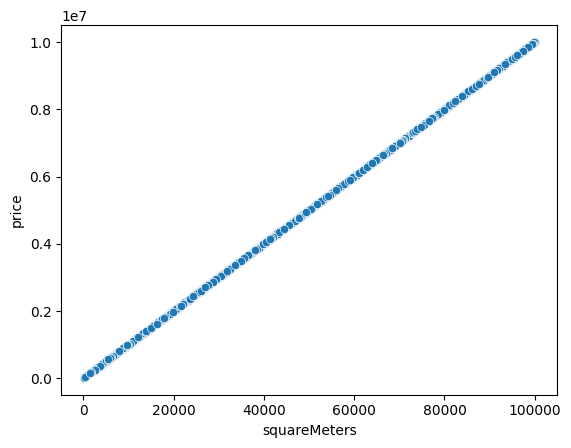

In [6]:
sns.scatterplot(x = 'squareMeters', y='price', data = df)

plt.show()

<Axes: xlabel='squareMeters'>

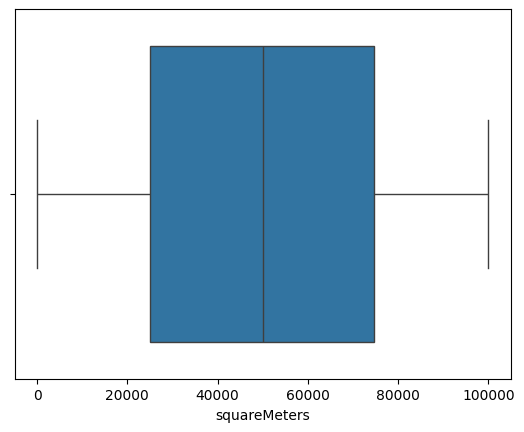

In [7]:
sns.boxplot(x = 'squareMeters', data = df)

<Axes: >

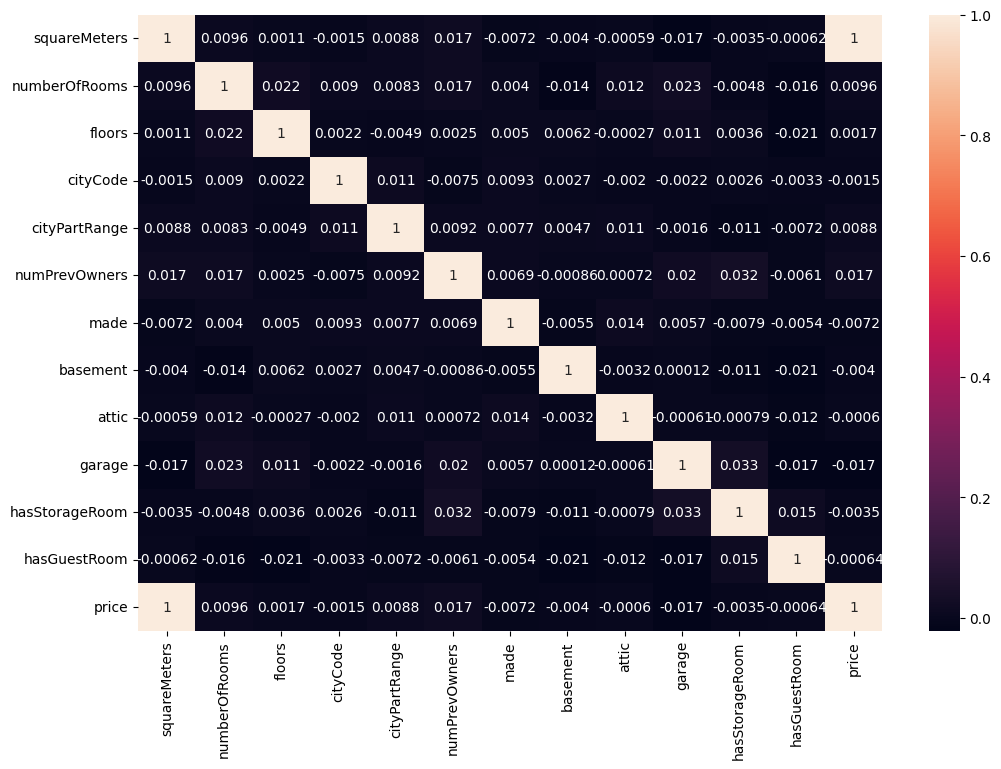

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [9]:
df.shape

(10000, 17)

### 3.

#### data cleaning

In [10]:
# drop the city code
df.drop('cityCode', axis = 1, inplace= True)


In [11]:
# FEATURE ENGINEERING
# get the age of property from the made year
df['propertyAge'] = 2026 - df['made']

# then drop the made column
df.drop('made', axis = 1, inplace= True)

In [12]:
df.head()

,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityPartRange,numPrevOwners,isNewBuilt,hasStormProtector,basement,attic,garage,hasStorageRoom,hasGuestRoom,price,propertyAge
0,75523,3,No,Yes,63,3,8,No,Yes,4313,9005,956,0,7,7559081.5,21
1,80771,39,Yes,Yes,98,8,6,Yes,No,3653,2436,128,1,2,8085989.5,11
2,55712,58,No,Yes,19,6,8,No,No,2937,8852,135,1,9,5574642.1,5
3,32316,47,No,No,6,10,4,No,Yes,659,7141,359,0,3,3232561.2,14
4,70429,19,Yes,Yes,90,3,7,Yes,No,8435,2429,292,1,4,7055052.0,36


#### use get_dummies to convert the following columns to numeric
hasYard, hasPool, isNewBuilt, hasstormprotector into numeric

In [13]:
df2 = pd.get_dummies(df, columns=['hasYard','hasPool','isNewBuilt','hasStormProtector'], drop_first=True).astype(int)
df2.head(3)

,squareMeters,numberOfRooms,floors,cityPartRange,numPrevOwners,basement,attic,garage,hasStorageRoom,hasGuestRoom,price,propertyAge,hasYard_Yes,hasPool_Yes,isNewBuilt_Yes,hasStormProtector_Yes
0,75523,3,63,3,8,4313,9005,956,0,7,7559081,21,0,1,0,1
1,80771,39,98,8,6,3653,2436,128,1,2,8085989,11,1,1,1,0
2,55712,58,19,6,8,2937,8852,135,1,9,5574642,5,0,1,0,0


### 4. Apply Linear regression

In [14]:
# seperate features and target variable (price)
x = df2.drop('price', axis=1)

# price
y = df['price']

#### train-test split: 80:20

In [15]:
# Split the dataset
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2)

# build model
model = LinearRegression()
lrmodel = model.fit(x_train, y_train)

In [16]:
print(f'Coefficient: {lrmodel.coef_}')
print(f'Intercept: {lrmodel.intercept_}')

Coefficient: [ 1.00000069e+02 -2.73741716e-01  5.47273596e+01  4.60730120e+01
 -8.74148472e-02 -9.92336785e-03 -2.67473794e-03  1.32555743e-01
  2.88409334e+01 -8.58127471e+00  2.69993713e+00  3.00012699e+03
  3.00041674e+03  1.07656578e+02  1.26435138e+02]
Intercept: 267.85000615380704


compute the model error


In [17]:
# evaluate your model
# we need mean absolute error
from sklearn.metrics import mean_absolute_error

# make predictions on the train set
train_pred = lrmodel.predict(x_train)

train_mae = mean_absolute_error(train_pred, y_train)
print('80:20 Train MAError is', train_mae)


# root mean squared error
from sklearn.metrics import root_mean_squared_error

train_rmse = root_mean_squared_error(train_pred, y_train)
print('80:20 Train RMSE is', train_rmse)

80:20 Train MAError is 1467.3583130178156
80:20 Train RMSE is 1889.1237390711492


make predictions on test set

In [18]:
# make predictions on test set
ypred = lrmodel.predict(x_test)

#evaluate the model
# MAE
test_mae = mean_absolute_error(ypred, y_test)
print('80:20 Test MAError is', test_mae)

# RMSE
test_rmse = root_mean_squared_error(ypred, y_test)
print('80:20 Test RMSE is', test_rmse)

80:20 Test MAError is 1522.8801910067368
80:20 Test RMSE is 1930.2513594628056


#### train-test 70:30

In [19]:
# Split the dataset
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3)

# build model
model = LinearRegression()
lrmodel = model.fit(x_train, y_train)

In [20]:
# make predictions on the train set
train_pred = lrmodel.predict(x_train)

# evaluate your model
# we need mean absolute error
from sklearn.metrics import mean_absolute_error

train_mae = mean_absolute_error(train_pred, y_train)
print('70:30 Train MAError is', train_mae)


# root mean squared error
from sklearn.metrics import root_mean_squared_error

train_rmse = root_mean_squared_error(train_pred, y_train)
print('70:30 Train RMSE is', train_rmse)

70:30 Train MAError is 1486.0640648065817
70:30 Train RMSE is 1905.333134472104


In [21]:
# make predictions on test set
ypred = lrmodel.predict(x_test)

#evaluate the model
# MAE
test_mae = mean_absolute_error(ypred, y_test)
print('70:30 Test MAError is', test_mae)

# RMSE
test_rmse = root_mean_squared_error(ypred, y_test)
print('70:30 Test RMSE is', test_rmse)

70:30 Test MAError is 1464.3310526650384
70:30 Test RMSE is 1880.6752133438442


#### train-test 85:15

In [22]:
# Split the dataset
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.15)

# build model
model = LinearRegression()
lrmodel = model.fit(x_train, y_train)

In [23]:
# make predictions on the train set
train_pred = lrmodel.predict(x_train)

# evaluate your model
# we need mean absolute error
from sklearn.metrics import mean_absolute_error

train_mae = mean_absolute_error(train_pred, y_train)
print('85:15 Train MAError is', train_mae)


# root mean squared error
from sklearn.metrics import root_mean_squared_error

train_rmse = root_mean_squared_error(train_pred, y_train)
print('85:15 Train RMSE is', train_rmse)

85:15 Train MAError is 1476.8082740986138
85:15 Train RMSE is 1897.5958638260888


In [24]:
# make predictions on test set
ypred = lrmodel.predict(x_test)

#evaluate the model
# MAE
test_mae = mean_absolute_error(ypred, y_test)
print('85:15 Test MAError is', test_mae)

# RMSE
test_rmse = root_mean_squared_error(ypred, y_test)
print('85:15 Test RMSE is', test_rmse)

85:15 Test MAError is 1485.827875517567
85:15 Test RMSE is 1895.8686645682535


get the influential factors plus their coefficients

In [25]:
coefs_df = pd.DataFrame({'feature': x.columns , 'coefficient': lrmodel.coef_})
coefs_df_sorted = coefs_df.sort_values(by= 'coefficient', ascending=False)
coefs_df

,feature,coefficient
0,squareMeters,100.000508
1,numberOfRooms,0.049975
2,floors,55.099165
3,cityPartRange,48.350703
4,numPrevOwners,-2.425413
5,basement,-0.001433
6,attic,-0.011152
7,garage,0.104620
8,hasStorageRoom,3.604775
9,hasGuestRoom,0.190796


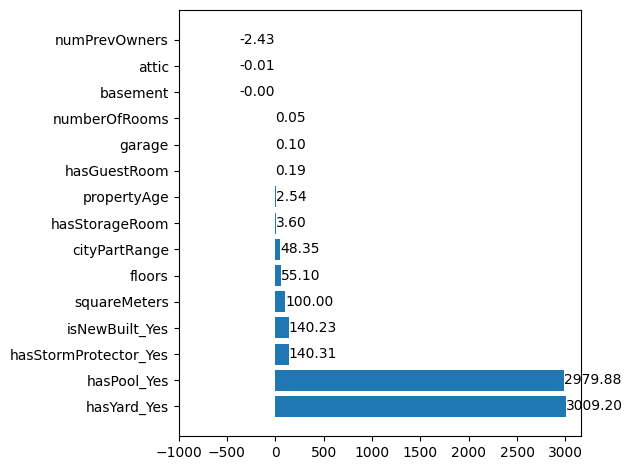

In [26]:
plt.barh(coefs_df_sorted['feature'], coefs_df_sorted['coefficient'])
plt.xlim(left=-1000)

# Add text labels for the coefficient values
for index, value in enumerate(coefs_df_sorted['coefficient']):
    plt.text(value, index, f'{value:.2f}', va='center', ha='left' if value >= 0 else 'right')

plt.tight_layout()
plt.show()